<a href="https://colab.research.google.com/github/werru-7/PUMP4.0_lecture01/blob/main/WR_pum5_regresjanieliniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [2]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_8576/2150386848.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 18.9k/18.9k [00:00<00:00, 23.8MB/s]

First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [3]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  20

In [4]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Zbuduj model benchmarkowy - zwykłą regresję liniową

In [5]:
regressor = LinearRegression().fit(X_train, y_train)
print(f"Współczynniki: {regressor.coef_}")
print(f"Wyraz wolny: {regressor.intercept_}")
print(f" R^2 {regressor.score(X_train, y_train)}")
print(f"Średni błąd absolutny z treningu: {mean_absolute_error(y_train, regressor.predict(X_train)):.2f}")

y_pred = regressor.predict(X_test)
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred):.2f}")

Współczynniki: [ 3400.65625     7384.17507075 15289.75305615    38.30848175
  2155.12465162]
Wyraz wolny: -63972.08387966572
 R^2 0.9043289032978942
Średni błąd absolutny z treningu: 11171.01
Średni błąd kwadratowy: 252493731.92
Średni błąd absolutny: 11377.18
Wyjaśniona wariancja: 0.89


Sprawdź czy w danych występuje współliniowość współczynnikiem VIF

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

X = X.drop('Age', axis=1)

               feature        VIF
0                  Age  15.191310
1               Gender   2.059767
2      Education Level   2.403316
3            Job Title   4.865563
4  Years of Experience   9.479247


Spróbuj poprawić wynik używając regresji LASSO

In [20]:
lasso_reg = Lasso(alpha=1)

# nauka na 70% danych
lasso_reg.fit(X_train, y_train)

# przewidywanie na 30% danych
y_pred_lasso = lasso_reg.predict(X_test)

# Wypisanie błędów
print("Wyniki dla LASSO:")
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred_lasso):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred_lasso):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred_lasso):.2f}")

Wyniki dla LASSO:
Średni błąd kwadratowy: 252498968.58
Średni błąd absolutny: 11377.16
Wyjaśniona wariancja: 0.89


Zbuduj dodatkową zmienną, kwadrat lat doświadczenia, zbuduj ponownie regresję


In [24]:
from sklearn.preprocessing import PolynomialFeatures

poly_2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly_2.fit_transform(X_train)
X_test_poly2 = poly_2.transform(X_test)

reg_poly2 = LinearRegression()
reg_poly2.fit(X_train_poly2, y_train)
y_pred_poly2 = reg_poly2.predict(X_test_poly2)

print("Regresja wielomianowa - stopień 2:")
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred_poly2):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred_poly2):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred_poly2):.2f}")

Regresja wielomianowa - stopień 2:
Średni błąd kwadratowy: 273235737.08
Średni błąd absolutny: 10664.19
Wyjaśniona wariancja: 0.88


In [26]:
poly_3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly_3.fit_transform(X_train)
X_test_poly3 = poly_3.transform(X_test)

reg_poly3 = LinearRegression()
reg_poly3.fit(X_train_poly3, y_train)
y_pred_poly3 = reg_poly3.predict(X_test_poly3)

print("Regresja wielomianowa - stopień 3:")
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred_poly3):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred_poly3):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred_poly3):.2f}")

Regresja wielomianowa - stopień 3:
Średni błąd kwadratowy: 437598719.06
Średni błąd absolutny: 11522.64
Wyjaśniona wariancja: 0.81


**Narysuj wykres typu scatterplot, dla zmiennych lata doświadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?**

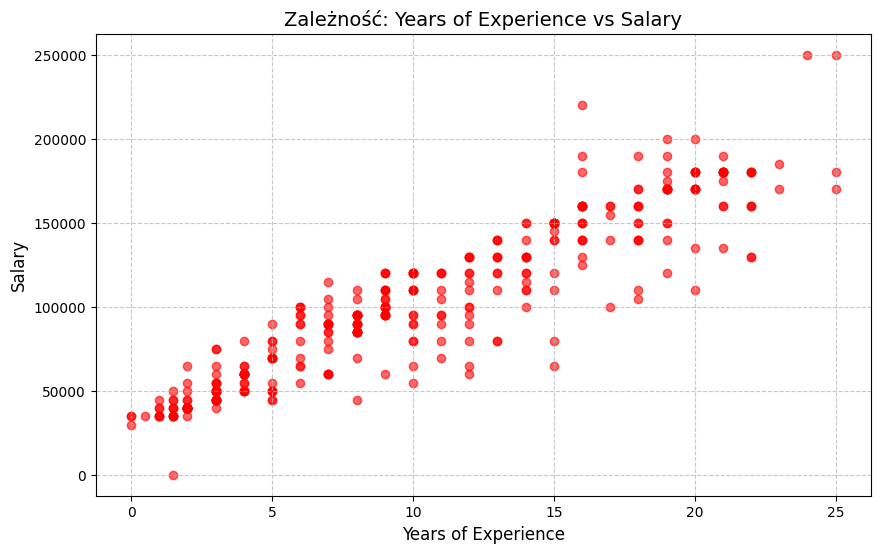

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Years of Experience'], df['Salary'], alpha=0.6, color='red')

plt.title('Zależność: Years of Experience vs Salary', fontsize=14)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Dla zmiennych lata doświadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?

Odpowiedź: Tak, jest uzasadniona. Zależnośc między Years of Experience a Salary jest nieliniowa (płaca wzrasta, ale zwalnia i tworzy łuk). Model jest bardziej elastyczny (wykreslenie krzywej między danymi). A liniowa, sztywna regresja stworzyłaby po prostu błędne prognozy.

Spróbuj wykorzystać regresje za pomocą K-NN
https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html#sphx-glr-auto-examples-neighbors-plot-regression-py

In [31]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5)

knn_reg.fit(X_train, y_train)

y_pred_knn = knn_reg.predict(X_test)

print("Wyniki dla regresji k-NN:")
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred_knn):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred_knn):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred_knn):.2f}")

Wyniki dla regresji k-NN:
Średni błąd kwadratowy: 329484129.46
Średni błąd absolutny: 12086.16
Wyjaśniona wariancja: 0.85


Regresja Liniowa: Średni R^2 = 0.888 (wahania: +/- 0.021)
Wielomian st. 2: Średni R^2 = 0.894 (wahania: +/- 0.018)
Wielomian st. 3: Średni R^2 = 0.874 (wahania: +/- 0.041)
k-NN: Średni R^2 = 0.840 (wahania: +/- 0.046)


/tmp/ipykernel_8576/2485006222.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(wyniki, labels=nazwy)


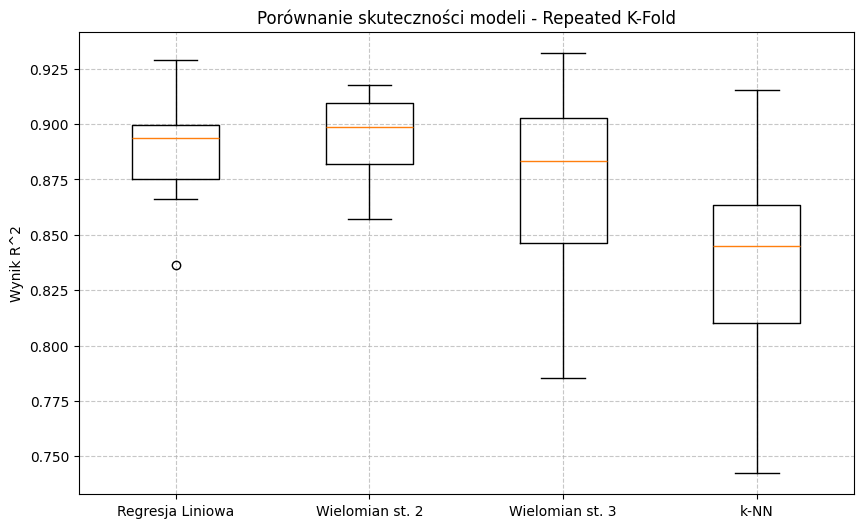

In [35]:
# Porównanie
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

modele = {
    "Regresja Liniowa": LinearRegression(),
    "Wielomian st. 2": make_pipeline(PolynomialFeatures(2), LinearRegression()),
    "Wielomian st. 3": make_pipeline(PolynomialFeatures(3), LinearRegression()),
    "k-NN": KNeighborsRegressor(n_neighbors=5)
}

wyniki = []
nazwy = []

for nazwa, model in modele.items():
    oceny = cross_val_score(model, X, y, cv=rkf, scoring='r2')
    wyniki.append(oceny)
    nazwy.append(nazwa)
    print(f"{nazwa}: Średni R^2 = {oceny.mean():.3f} (wahania: +/- {oceny.std():.3f})")

plt.figure(figsize=(10, 6))
plt.boxplot(wyniki, labels=nazwy)
plt.title('Porównanie skuteczności modeli - Repeated K-Fold')
plt.ylabel('Wynik R^2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()